In [2]:
# %% Cell 1 — Imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.cosmology import FlatLambdaCDM
 

In [3]:

# %% Cell 2 — Load catalogs
phot_hdu = fits.open('../data/UNCOVER_DR4_SPS_catalog.fits')
spec_hdu = fits.open('../data/UNCOVER_DR4_SPS_zspec_catalog.fits')
phot = phot_hdu[1].data
spec = spec_hdu[1].data
print(f"Photometric catalog: {len(phot)} galaxies")
print(f"Spectroscopic catalog: {len(spec)} galaxies")
 

Photometric catalog: 74020 galaxies
Spectroscopic catalog: 668 galaxies


In [5]:
# %% Cell 3 — Cosmology for volume calculation
# Planck 2018 (matches your CLASS parameters)
h = 0.6774
cosmo_model = FlatLambdaCDM(H0=100*h, Om0=0.3089, Tcmb0=2.7255, Ob0=0.0486)

# UNCOVER survey geometry
# Bezanson+2022: 45 arcmin^2 effective area
UNCOVER_AREA_ARCMIN2 = 45.0
FULLSKY_ARCMIN2 = (180/np.pi)**2 * 4 * np.pi * 60**2  # ~1.485e8
SKY_FRACTION = UNCOVER_AREA_ARCMIN2 / FULLSKY_ARCMIN2
print(f"Survey area: {UNCOVER_AREA_ARCMIN2} arcmin^2")
print(f"Sky fraction: {SKY_FRACTION:.3e}")

Survey area: 45.0 arcmin^2
Sky fraction: 3.030e-07


In [7]:

# %% Cell 4 — Quality cuts
#
# PHOTOMETRIC: Hashim's cut from his notebook
#   - z_16, z_84 not NaN
#   - (z_50 - z_16) <= 1   (lower z uncertainty reasonable)
#   - (z_84 - z_50) <= 1   (upper z uncertainty reasonable)
#   - mstar_50 not NaN
#
# This is MORE restrictive than just use_phot=1.
# It removes galaxies with wildly uncertain redshifts,
# including catastrophic photo-z failures at z>12.
 
phot_mask = (
    (~np.isnan(phot['z_16'])) &
    (~np.isnan(phot['z_84'])) &
    ((phot['z_50'] - phot['z_16']) <= 1.0) &
    ((phot['z_84'] - phot['z_50']) <= 1.0) &
    (~np.isnan(phot['mstar_50']))
)
print(f"Photometric galaxies passing quality cuts: {phot_mask.sum()} / {len(phot)}")


# SPECTROSCOPIC: quality flags + valid mass
spec_mask = (
    (spec['flag_zspec_qual'] >= 2) &
    (spec['flag_successful_spectrum'] == 1) &
    (~np.isnan(spec['mstar_50']))
)
print(f"Spectroscopic galaxies passing quality cuts: {spec_mask.sum()} / {len(spec)}")

Photometric galaxies passing quality cuts: 41566 / 74020
Spectroscopic galaxies passing quality cuts: 388 / 668


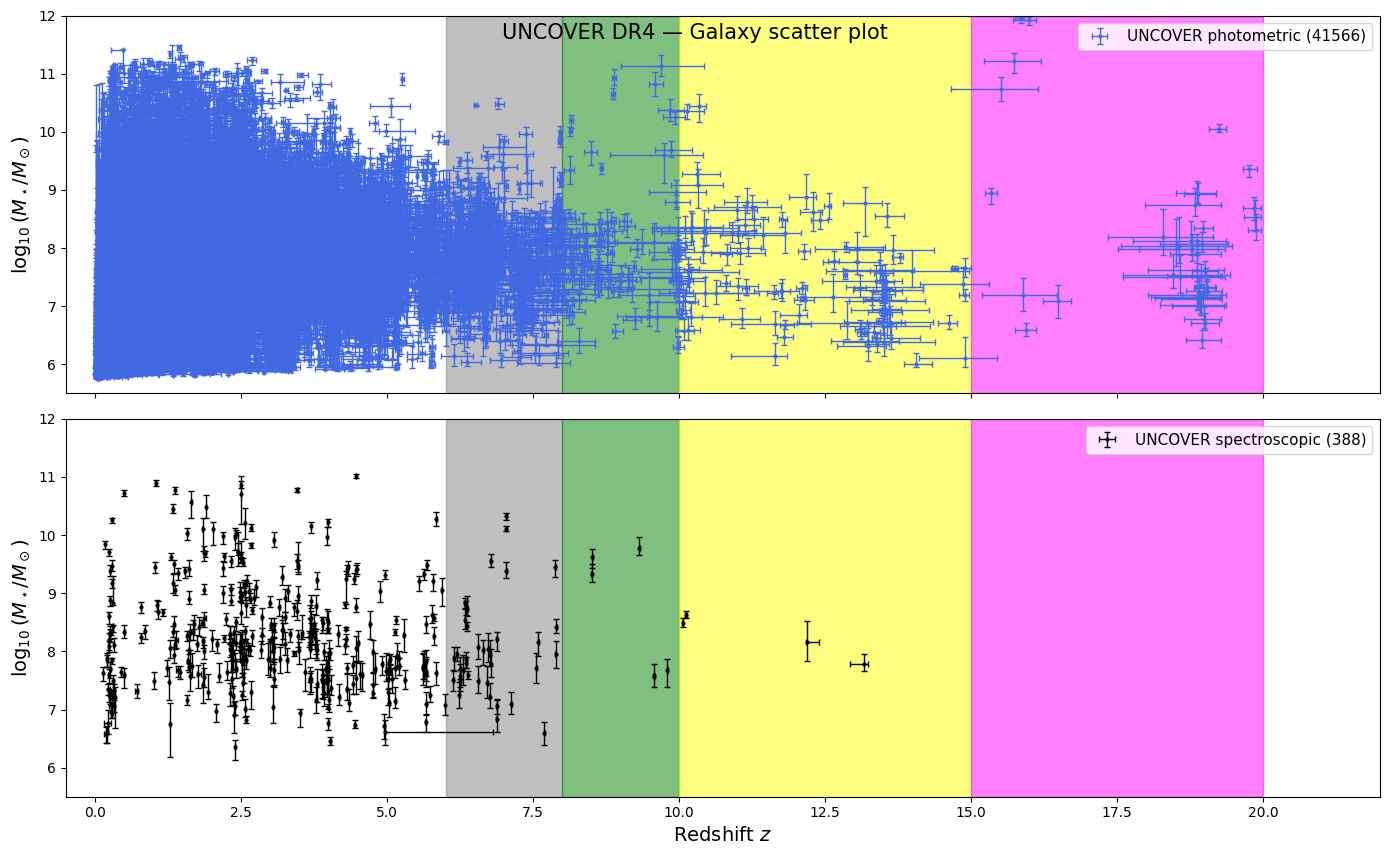

In [10]:

# %% Cell 5 — Reproduce Hashim's scatter plot (your screenshot)
#
# Top panel: photometric galaxies (blue) with error bars
# Bottom panel: spectroscopic galaxies (black) with error bars
# Colored bands: redshift bins
 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.0)
 
# --- Photometric (top) ---
p = phot[phot_mask]
ax1.errorbar(
    p['z_50'], p['mstar_50'],
    xerr=[p['z_50'] - p['z_16'], p['z_84'] - p['z_50']],
    yerr=[p['mstar_50'] - p['mstar_16'], p['mstar_84'] - p['mstar_50']],
    fmt='.', capsize=2, elinewidth=1.0, color='royalblue', ms=4,
    label=f'UNCOVER photometric ({phot_mask.sum()})'
)
 
# --- Spectroscopic (bottom) ---
s = spec[spec_mask]
ax2.errorbar(
    s['z_spec'], s['mstar_50'],
    xerr=[s['z_spec50'] - s['z_spec16'], s['z_spec84'] - s['z_spec50']],
    yerr=[s['mstar_50'] - s['mstar_16'], s['mstar_84'] - s['mstar_50']],
    fmt='.', capsize=2, elinewidth=1.0, color='black', ms=4,
    label=f'UNCOVER spectroscopic ({spec_mask.sum()})'
)
 
# --- Redshift bins (Hashim's binning from his notebook) ---
for ax in [ax1, ax2]:
    ax.axvspan(6, 8, color='gray', alpha=0.5)
    ax.axvspan(8, 10, color='green', alpha=0.5)
    ax.axvspan(10, 15, color='yellow', alpha=0.5)
    ax.axvspan(15, 20, color='magenta', alpha=0.5)
    ax.set_ylabel(r'$\log_{10}(M_\star / M_\odot)$', fontsize=14)
    ax.legend(fontsize=11, loc='upper right')

ax1.set_xlim(-0.5, 22)
ax1.set_ylim(5.5, 12)
ax2.set_xlabel('Redshift $z$', fontsize=14)
fig.suptitle('UNCOVER DR4 — Galaxy scatter plot', fontsize=15, y=0.93)
plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:

# %% Cell 6 — Function to compute observed rho_star(>M_star)
#
# This is the core data-side calculation.
# For each redshift bin:
#   1. Select galaxies in the bin
#   2. Sort by stellar mass (highest first)
#   3. Cumulative sum of (M_star * mu) / V_survey
#      where mu is the magnification (volume correction)
#   4. Error bars from mstar_16 and mstar_84
#
# WHY magnification weighting:
#   A galaxy with mu=3 was found in an effective volume 3x smaller
#   than the geometric volume. To get the TRUE density, we must
#   upweight it by mu. Without this, we undercount the real density.
 
def compute_rho_star_obs(catalog, z_col, m50_col, m16_col, m84_col,
                          mu_col, zbin_lo, zbin_hi, mask,
                          use_magnification=True):
    """
    Compute observed cumulative stellar mass density rho_star(>M_star)
    in a redshift bin.
 
    Parameters
    ----------
    catalog : FITS record array
    z_col   : str, column name for redshift
    m50_col : str, column name for median log10(M_star/Msun)
    m16_col : str, column name for 16th percentile log10(M_star)
    m84_col : str, column name for 84th percentile log10(M_star)
    mu_col  : str, column name for lensing magnification
    zbin_lo, zbin_hi : float, redshift bin edges
    mask    : boolean array, quality cut mask
    use_magnification : bool, whether to apply mu correction
 
    Returns
    -------
    dict with keys:
        'Mstar_50'  : array, stellar masses (linear, sorted descending)
        'Mstar_16'  : array, lower bound masses
        'Mstar_84'  : array, upper bound masses
        'rho_50'    : array, cumulative stellar mass density (median)
        'rho_16'    : array, cumulative stellar mass density (lower)
        'rho_84'    : array, cumulative stellar mass density (upper)
        'volume'    : float, comoving survey volume in Mpc^3
        'n_galaxies': int, number of galaxies in this bin
    """
    # Select galaxies in redshift bin
    zbin_mask = mask & (catalog[z_col] >= zbin_lo) & (catalog[z_col] < zbin_hi)
    n_gal = zbin_mask.sum()
 
    if n_gal == 0:
        return {'n_galaxies': 0}
 
    # Survey volume for this bin
    V_full = (cosmo_model.comoving_volume(zbin_hi).value -
              cosmo_model.comoving_volume(zbin_lo).value)  # Mpc^3, full sky
    V_survey = V_full * SKY_FRACTION  # Mpc^3, UNCOVER footprint
 
    # Extract masses (convert from log to linear)
    log_m50 = catalog[m50_col][zbin_mask]
    log_m16 = catalog[m16_col][zbin_mask]
    log_m84 = catalog[m84_col][zbin_mask]
 
    # Sort by median mass, DESCENDING
    sort_idx = np.argsort(log_m50)[::-1]
    M50 = 10**log_m50[sort_idx]  # M_sun
    M16 = 10**log_m16[sort_idx]
    M84 = 10**log_m84[sort_idx]
 
    # Magnification
    if use_magnification and mu_col is not None:
        mu = catalog[mu_col][zbin_mask][sort_idx]
        # Clip magnification to minimum 1.0 (can't demagnify behind cluster)
        mu = np.clip(mu, 1.0, None)
    else:
        mu = np.ones(n_gal)
 
    # Cumulative stellar mass density
    # Each galaxy contributes M_star * mu to the running total
    # (mu corrects for the smaller effective volume)
    rho_50 = np.cumsum(M50 * mu) / V_survey  # M_sun / Mpc^3
    rho_16 = np.cumsum(M16 * mu) / V_survey
    rho_84 = np.cumsum(M84 * mu) / V_survey
 
    return {
        'Mstar_50': M50,
        'Mstar_16': M16,
        'Mstar_84': M84,
        'rho_50': rho_50,
        'rho_16': rho_16,
        'rho_84': rho_84,
        'volume': V_survey,
        'n_galaxies': n_gal,
        'mu': mu,
    }
 
# %% Cell 7 — Compute rho_star for all redshift bins
#
# Using Hashim's binning: 6-8, 8-10, 10-15, 15-20
# Both photometric and spectroscopic
 
zbins = [(6, 8), (8, 10), (10, 15), (15, 20)]
 
results_phot = {}
results_spec = {}
 
for zlo, zhi in zbins:
    label = f'z={zlo}-{zhi}'
 
    # Photometric
    results_phot[label] = compute_rho_star_obs(
        phot, 'z_50', 'mstar_50', 'mstar_16', 'mstar_84', 'mu_num_50',
        zlo, zhi, phot_mask, use_magnification=True
    )
 
    # Spectroscopic
    results_spec[label] = compute_rho_star_obs(
        spec, 'z_spec', 'mstar_50', 'mstar_16', 'mstar_84', 'mu_num_50',
        zlo, zhi, spec_mask, use_magnification=True
    )
 
    n_p = results_phot[label]['n_galaxies']
    n_s = results_spec[label]['n_galaxies']
    print(f"{label}:  phot={n_p:>5d}  spec={n_s:>3d}  "
          f"V={results_phot[label].get('volume', 0):.2e} Mpc^3")
 

z=6-8:  phot=  787  spec= 38  V=2.08e+05 Mpc^3
z=8-10:  phot=  100  spec=  5  V=1.70e+05 Mpc^3
z=10-15:  phot=  112  spec=  4  V=3.15e+05 Mpc^3
z=15-20:  phot=   44  spec=  0  V=2.21e+05 Mpc^3


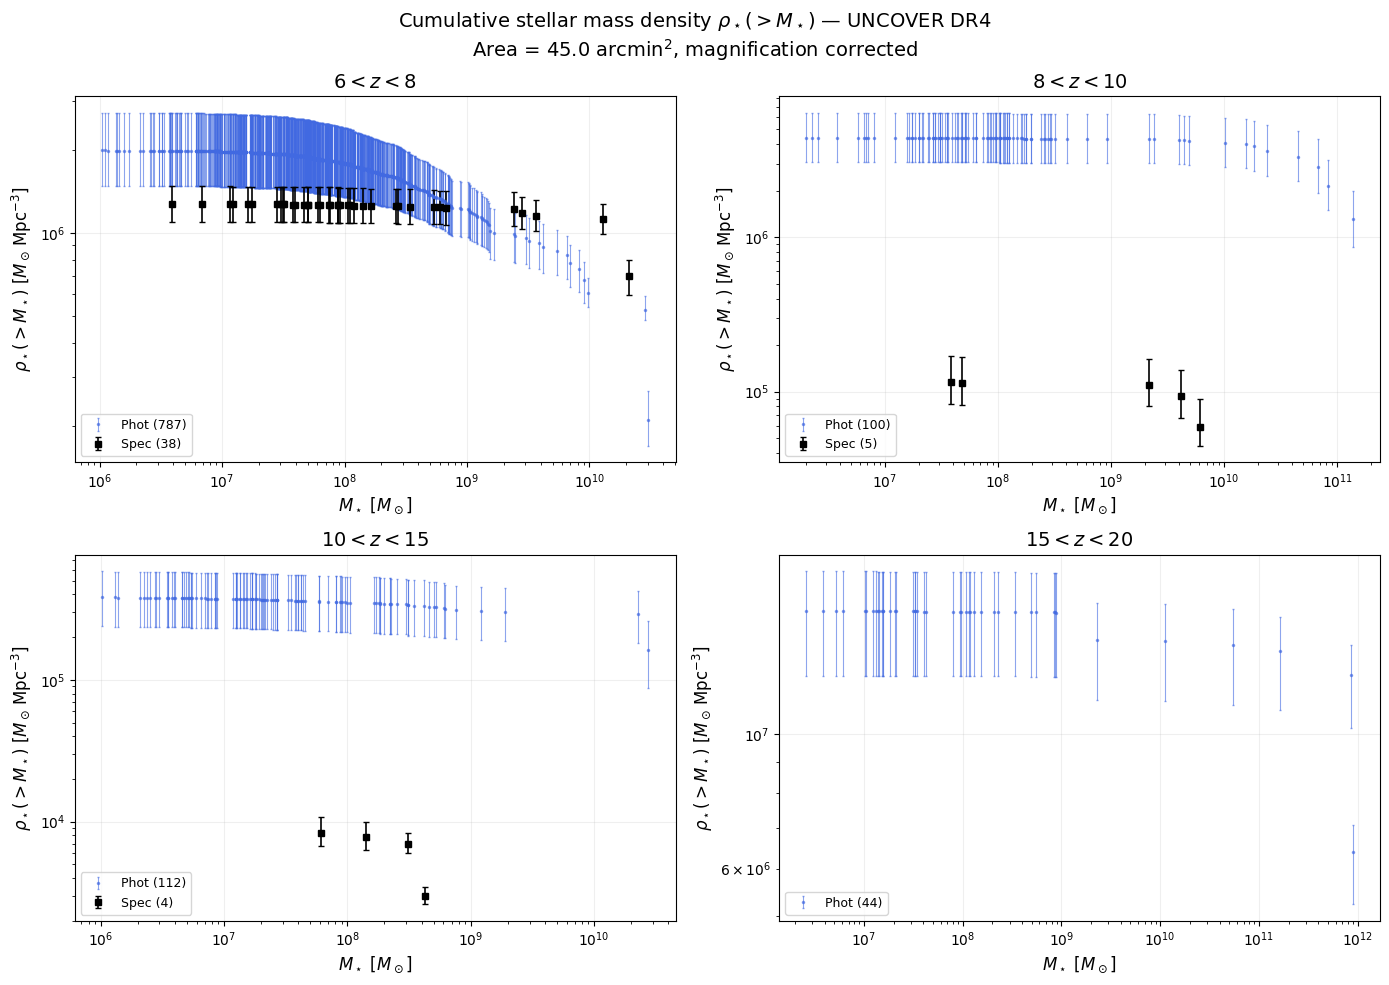

In [12]:

# %% Cell 8 — The "quarter circle" plots: rho_star(>M_star) per redshift bin
#
# One panel per redshift bin.
# x-axis: M_star (the threshold mass)
# y-axis: rho_star(>M_star) = total stellar mass density in galaxies
#         more massive than that threshold
# Blue: photometric, Black: spectroscopic
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
 
for idx, (zlo, zhi) in enumerate(zbins):
    ax = axes[idx]
    label = f'z={zlo}-{zhi}'
    rp = results_phot[label]
    rs = results_spec[label]
 
    # Photometric
    if rp['n_galaxies'] > 0:
        ax.errorbar(
            rp['Mstar_50'], rp['rho_50'],
            yerr=[rp['rho_50'] - rp['rho_16'],
                  rp['rho_84'] - rp['rho_50']],
            fmt='.', capsize=1, elinewidth=0.8, color='royalblue',
            ms=3, alpha=0.6, label=f'Phot ({rp["n_galaxies"]})'
        )
 
    # Spectroscopic
    if rs['n_galaxies'] > 0:
        ax.errorbar(
            rs['Mstar_50'], rs['rho_50'],
            yerr=[rs['rho_50'] - rs['rho_16'],
                  rs['rho_84'] - rs['rho_50']],
            fmt='s', capsize=2, elinewidth=1.2, color='black',
            ms=4, label=f'Spec ({rs["n_galaxies"]})'
        )
 
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$M_\star$ [$M_\odot$]', fontsize=12)
    ax.set_ylabel(r'$\rho_\star(>M_\star)$ [$M_\odot\,\mathrm{Mpc}^{-3}$]',
                  fontsize=12)
    ax.set_title(f'${zlo} < z < {zhi}$', fontsize=14)
    ax.legend(fontsize=9, loc='lower left')
    ax.grid(True, alpha=0.2)

plt.suptitle(r'Cumulative stellar mass density $\rho_\star(>M_\star)$ — UNCOVER DR4'
             f'\nArea = {UNCOVER_AREA_ARCMIN2} arcmin$^2$, magnification corrected',
             fontsize=14)
plt.tight_layout()
plt.savefig('rho_star_quarter_circle.png', dpi=150, bbox_inches='tight')
plt.show()
 

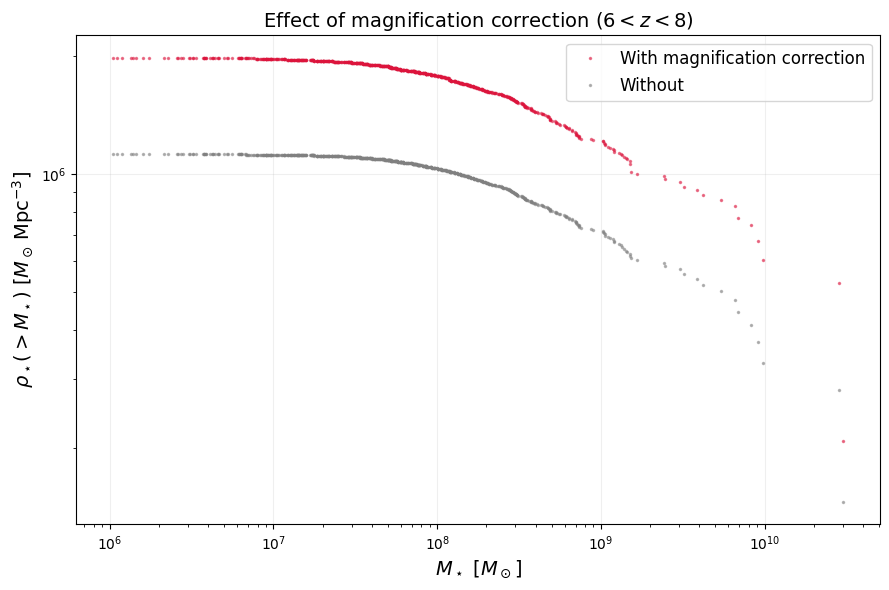

Magnification effect on most massive galaxy: rho_with_mu / rho_without = 1.43
Most massive galaxy has mu = 1.43


In [15]:

# %% Cell 9 — Same plot WITHOUT magnification (for comparison)
#
# This reproduces what Hashim's notebook does (no mu correction).
# Compare to see how much difference magnification makes.
 
results_phot_nomu = {}
for zlo, zhi in zbins:
    label = f'z={zlo}-{zhi}'
    results_phot_nomu[label] = compute_rho_star_obs(
        phot, 'z_50', 'mstar_50', 'mstar_16', 'mstar_84', 'mu_num_50',
        zlo, zhi, phot_mask, use_magnification=False
    )

# Plot comparison for the most populated bin (z=6-8)
fig, ax = plt.subplots(figsize=(9, 6))
label = 'z=6-8'
rp_mu   = results_phot[label]
rp_nomu = results_phot_nomu[label]
 
ax.plot(rp_mu['Mstar_50'], rp_mu['rho_50'],
        '.', color='crimson', ms=3, alpha=0.5,
        label=f'With magnification correction')
ax.plot(rp_nomu['Mstar_50'], rp_nomu['rho_50'],
        '.', color='gray', ms=3, alpha=0.5,
        label=f'Without')
 
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_\star$ [$M_\odot$]', fontsize=14)
ax.set_ylabel(r'$\rho_\star(>M_\star)$ [$M_\odot\,\mathrm{Mpc}^{-3}$]', fontsize=14)
ax.set_title(f'Effect of magnification correction ($6 < z < 8$)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('magnification_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Print the ratio at the high-mass end
if rp_mu['n_galaxies'] > 2:
    ratio_top = rp_mu['rho_50'][0] / rp_nomu['rho_50'][0]
    print(f"Magnification effect on most massive galaxy: "
          f"rho_with_mu / rho_without = {ratio_top:.2f}")
    print(f"Most massive galaxy has mu = {rp_mu['mu'][0]:.2f}")
 

In [14]:

# %% Cell 10 — Summary statistics per bin
print("\n" + "=" * 70)
print("SUMMARY: Observed cumulative stellar mass density")
print(f"Survey area: {UNCOVER_AREA_ARCMIN2} arcmin^2, magnification corrected")
print("=" * 70)
 
for zlo, zhi in zbins:
    label = f'z={zlo}-{zhi}'
    rp = results_phot[label]
    rs = results_spec[label]
 
    print(f"\n{label}:")
    print(f"  Volume: {rp.get('volume', 0):.2e} Mpc^3")
 
    if rp['n_galaxies'] > 0:
        print(f"  Photometric: {rp['n_galaxies']} galaxies")
        print(f"    Most massive: log(M*) = {np.log10(rp['Mstar_50'][0]):.2f}")
        print(f"    rho_star(>M_max) = {rp['rho_50'][0]:.2e} Msun/Mpc^3")
        print(f"    rho_star(total)  = {rp['rho_50'][-1]:.2e} Msun/Mpc^3")
 
    if rs['n_galaxies'] > 0:
        print(f"  Spectroscopic: {rs['n_galaxies']} galaxies")
        print(f"    Most massive: log(M*) = {np.log10(rs['Mstar_50'][0]):.2f}")

phot_hdu.close()
spec_hdu.close()
 


SUMMARY: Observed cumulative stellar mass density
Survey area: 45.0 arcmin^2, magnification corrected

z=6-8:
  Volume: 2.08e+05 Mpc^3
  Photometric: 787 galaxies
    Most massive: log(M*) = 10.48
    rho_star(>M_max) = 2.09e+05 Msun/Mpc^3
    rho_star(total)  = 1.99e+06 Msun/Mpc^3
  Spectroscopic: 38 galaxies
    Most massive: log(M*) = 10.33

z=8-10:
  Volume: 1.70e+05 Mpc^3
  Photometric: 100 galaxies
    Most massive: log(M*) = 11.14
    rho_star(>M_max) = 1.31e+06 Msun/Mpc^3
    rho_star(total)  = 4.41e+06 Msun/Mpc^3
  Spectroscopic: 5 galaxies
    Most massive: log(M*) = 9.78

z=10-15:
  Volume: 3.15e+05 Mpc^3
  Photometric: 112 galaxies
    Most massive: log(M*) = 10.44
    rho_star(>M_max) = 1.62e+05 Msun/Mpc^3
    rho_star(total)  = 3.82e+05 Msun/Mpc^3
  Spectroscopic: 4 galaxies
    Most massive: log(M*) = 8.63

z=15-20:
  Volume: 2.21e+05 Mpc^3
  Photometric: 44 galaxies
    Most massive: log(M*) = 11.95
    rho_star(>M_max) = 6.38e+06 Msun/Mpc^3
    rho_star(total)  = 1.60